<a href="https://colab.research.google.com/github/User-2rxeg/Power-Usage-Forecast-ML/blob/main/Power_Consumption_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 3: Load the data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("✅ Data loaded successfully!")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print("\n📊 Training set columns:")
print(train_df.columns.tolist())

✅ Data loaded successfully!
Training set shape: (27999, 12)
Test set shape: (7041, 11)

📊 Training set columns:
['Id', 'date', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Usage_kWh']


In [3]:
# Cell 4: First glimpse of the data
print("🔍 FIRST LOOK AT TRAINING DATA:")
print("=" * 50)
display(train_df.head())

print("\n📝 DATA TYPES AND MISSING VALUES:")
print("=" * 50)
print(train_df.info())

print("\n❓ MISSING VALUES SUMMARY:")
print("=" * 50)
missing_data = train_df.isnull().sum()
print(missing_data[missing_data > 0])

🔍 FIRST LOOK AT TRAINING DATA:


,Id,date,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Usage_kWh
0,1,1/1/2018 0:15,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,3.17
1,2,1/1/2018 0:30,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,4.00
2,3,1/1/2018 0:45,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,3.24
3,4,1/1/2018 1:00,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,3.31
4,5,1/1/2018 1:15,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,3.82



📝 DATA TYPES AND MISSING VALUES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27999 entries, 0 to 27998
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Id                                    27999 non-null  int64  
 1   date                                  27999 non-null  object 
 2   Lagging_Current_Reactive.Power_kVarh  27999 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  27880 non-null  float64
 4   CO2(tCO2)                             27999 non-null  float64
 5   Lagging_Current_Power_Factor          27999 non-null  float64
 6   Leading_Current_Power_Factor          27923 non-null  float64
 7   NSM                                   27999 non-null  int64  
 8   WeekStatus                            26225 non-null  object 
 9   Day_of_week                           26225 non-null  object 
 10  Load_Type                             27999 non-

🎯 TARGET VARIABLE ANALYSIS: Usage_kWh
Basic statistics:
count    27999.000000
mean        27.888785
std         33.919271
min          2.450000
25%          3.130000
50%          4.570000
75%         51.190000
max        153.140000
Name: Usage_kWh, dtype: float64


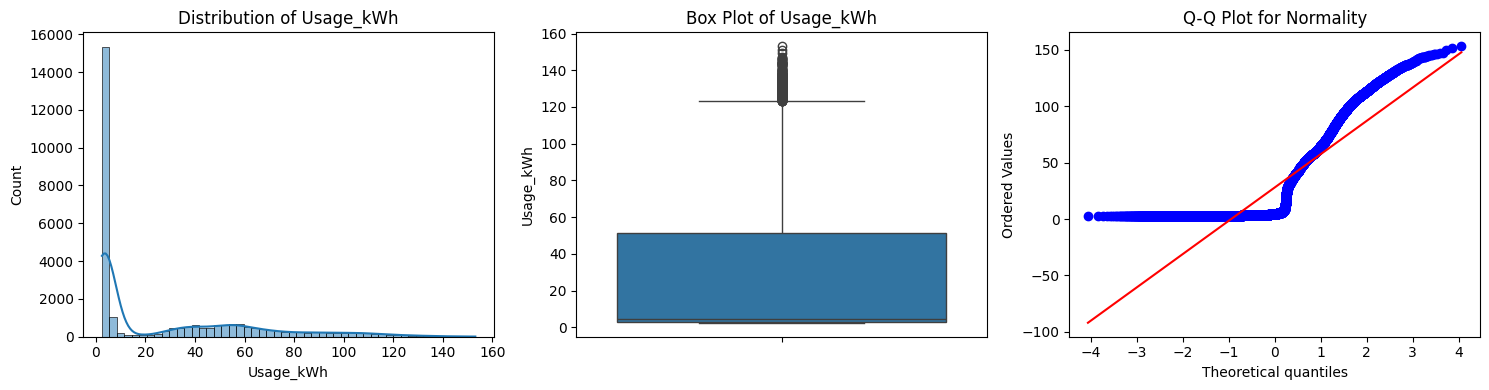

In [4]:
# Cell 5: Analyze Usage_kWh (our target variable)
print("🎯 TARGET VARIABLE ANALYSIS: Usage_kWh")
print("=" * 50)

# Basic statistics
print("Basic statistics:")
print(train_df['Usage_kWh'].describe())

# Create visualization
plt.figure(figsize=(15, 4))

# Distribution
plt.subplot(1, 3, 1)
sns.histplot(train_df['Usage_kWh'], kde=True, bins=50)
plt.title('Distribution of Usage_kWh')
plt.xlabel('Usage_kWh')

# Box plot
plt.subplot(1, 3, 2)
sns.boxplot(y=train_df['Usage_kWh'])
plt.title('Box Plot of Usage_kWh')

# Q-Q plot for normality check
plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(train_df['Usage_kWh'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality')

plt.tight_layout()
plt.show()

In [5]:
# Cell 6: Examine categorical features
print("📋 CATEGORICAL FEATURES ANALYSIS")
print("=" * 50)

categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']

for col in categorical_cols:
    if col in train_df.columns:
        print(f"\n{col}:")
        print(train_df[col].value_counts())
        print(f"Unique values: {train_df[col].nunique()}")
    else:
        print(f"\n⚠️ Column '{col}' not found in dataset")

📋 CATEGORICAL FEATURES ANALYSIS

WeekStatus:
WeekStatus
Weekday    18929
Weekend     7296
Name: count, dtype: int64
Unique values: 2

Day_of_week:
Day_of_week
Tuesday      3840
Wednesday    3830
Monday       3804
Thursday     3744
Friday       3711
Saturday     3648
Sunday       3648
Name: count, dtype: int64
Unique values: 7

Load_Type:
Load_Type
Light_Load      14364
Medium_Load      7784
Maximum_Load     5851
Name: count, dtype: int64
Unique values: 3


In [6]:
# Cell 7: Handle Missing Values
print("🔧 HANDLING MISSING VALUES")
print("=" * 50)

print("Missing values before treatment:")
print(f"Leading_Current_Reactive_Power_kVarh: {train_df['Leading_Current_Reactive_Power_kVarh'].isnull().sum()}")
print(f"Leading_Current_Power_Factor: {train_df['Leading_Current_Power_Factor'].isnull().sum()}")
print(f"WeekStatus & Day_of_week: {train_df['WeekStatus'].isnull().sum()}")

# Strategy for missing values
# For numerical columns - fill with median
train_df['Leading_Current_Reactive_Power_kVarh'].fillna(
    train_df['Leading_Current_Reactive_Power_kVarh'].median(), inplace=True)
train_df['Leading_Current_Power_Factor'].fillna(
    train_df['Leading_Current_Power_Factor'].median(), inplace=True)

# For categorical columns - we need to derive them from date
# First, let's check what's special about rows with missing WeekStatus/Day_of_week
missing_dates = train_df[train_df['WeekStatus'].isnull()]['date']
print(f"\nDates with missing categorical data (first 5):")
print(missing_dates.head())

print("\n✅ Missing values treated (numerical columns filled with median)")

🔧 HANDLING MISSING VALUES
Missing values before treatment:
Leading_Current_Reactive_Power_kVarh: 119
Leading_Current_Power_Factor: 76
WeekStatus & Day_of_week: 1774

Dates with missing categorical data (first 5):
10358    18/04/2018 21:45
10359    18/04/2018 22:00
10360    18/04/2018 22:15
10361    18/04/2018 22:30
10362    18/04/2018 22:45
Name: date, dtype: object

✅ Missing values treated (numerical columns filled with median)


/tmp/ipython-input-1003959827.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Leading_Current_Reactive_Power_kVarh'].fillna(
/tmp/ipython-input-1003959827.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [10]:
# Cell 8: Feature Engineering from Date
print("📅 FEATURE ENGINEERING FROM DATE COLUMN")
print("=" * 50)

# Convert date to datetime
train_df['date'] = pd.to_datetime(train_df['date'], format='%d/%m/%Y %H:%M', dayfirst=True)
test_df['date'] = pd.to_datetime(test_df['date'], format='%d/%m/%Y %H:%M', dayfirst=True)

# Extract powerful temporal features
def create_date_features(df):
    df = df.copy()
    df['hour'] = df['date'].dt.hour
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    df['season'] = (df['month'] % 12 + 3) // 3  # 1:Winter, 2:Spring, 3:Summer, 4:Fall

    # Fix missing WeekStatus and Day_of_week using the actual dates
    if 'WeekStatus' in df.columns:
        mask = df['WeekStatus'].isnull()
        df.loc[mask, 'WeekStatus'] = df.loc[mask, 'date'].dt.dayofweek.apply(
            lambda x: 'Weekend' if x >= 5 else 'Weekday'
        )

    if 'Day_of_week' in df.columns:
        mask = df['Day_of_week'].isnull()
        days = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
                4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
        df.loc[mask, 'Day_of_week'] = df.loc[mask, 'date'].dt.dayofweek.map(days)

    return df

# Apply to both train and test
train_df = create_date_features(train_df)
test_df = create_date_features(test_df)

print("✅ New features created:")
new_features = ['hour', 'day_of_month', 'month', 'day_of_year', 'is_weekend', 'season']
for feature in new_features:
    print(f"  - {feature}")

print(f"\nTraining set shape after feature engineering: {train_df.shape}")

📅 FEATURE ENGINEERING FROM DATE COLUMN
✅ New features created:
  - hour
  - day_of_month
  - month
  - day_of_year
  - is_weekend
  - season

Training set shape after feature engineering: (27999, 18)


📈 CORRELATION WITH TARGET VARIABLE
Correlation with Usage_kWh:
  CO2(tCO2)............................... +0.9872
  Lagging_Current_Reactive.Power_kVarh.... +0.8880
  Lagging_Current_Power_Factor............ +0.4059
  Leading_Current_Power_Factor............ +0.3540
  NSM..................................... +0.2397
  Id...................................... -0.1349
  Leading_Current_Reactive_Power_kVarh.... -0.3224


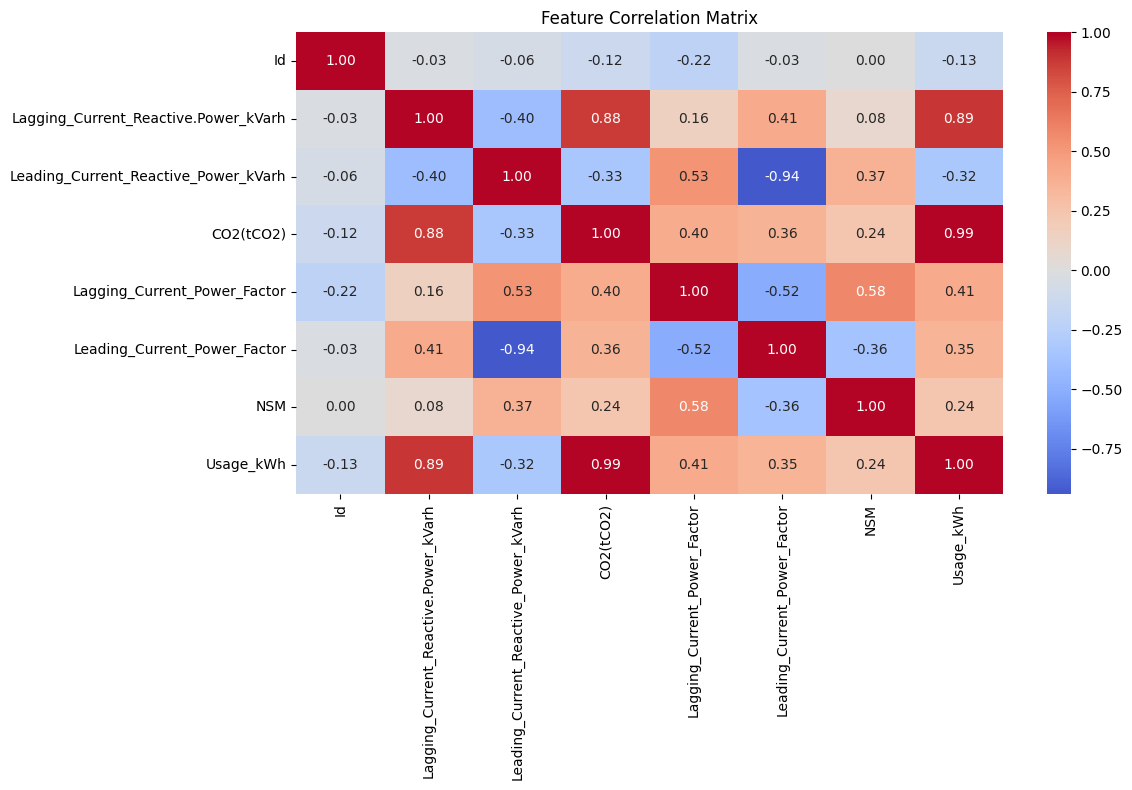

In [8]:
# Cell 9: Correlation Analysis
print("📈 CORRELATION WITH TARGET VARIABLE")
print("=" * 50)

# Select numerical columns for correlation
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_with_target = train_df[numerical_cols].corr()['Usage_kWh'].sort_values(ascending=False)

print("Correlation with Usage_kWh:")
for feature, corr in correlation_with_target.items():
    if feature != 'Usage_kWh':  # Don't show correlation with itself
        print(f"  {feature:.<40} {corr:+.4f}")

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = train_df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

👀 EXPLORATORY VISUALIZATIONS


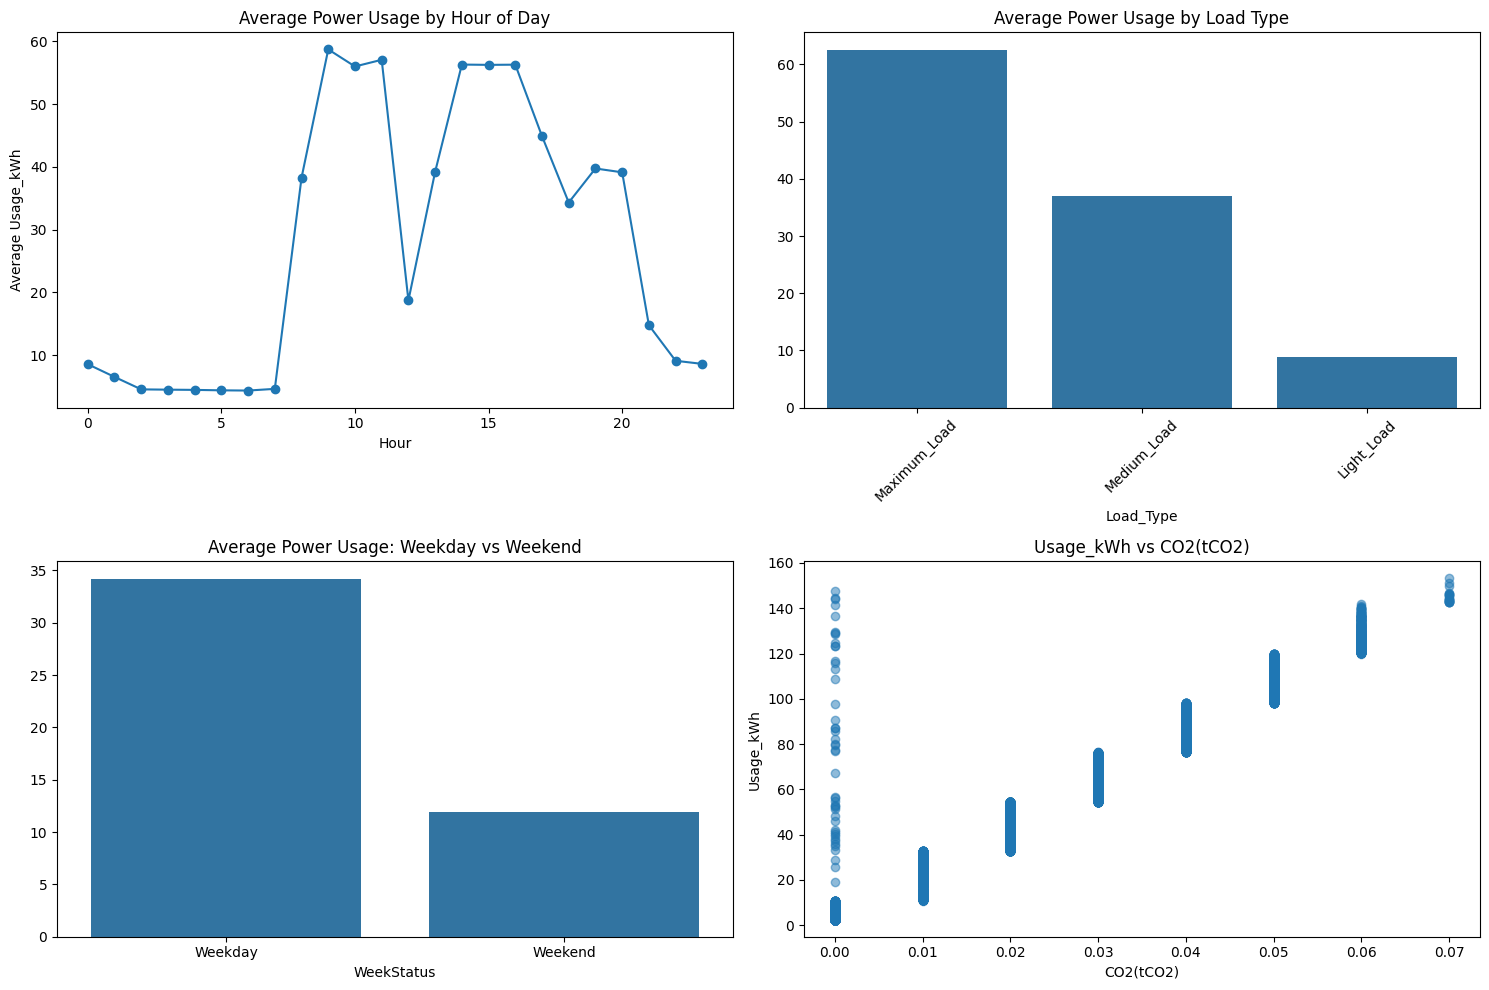

In [11]:
# Cell 10: Feature Visualization
print("👀 EXPLORATORY VISUALIZATIONS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Usage by hour of day
hourly_usage = train_df.groupby('hour')['Usage_kWh'].mean()
axes[0,0].plot(hourly_usage.index, hourly_usage.values, marker='o')
axes[0,0].set_title('Average Power Usage by Hour of Day')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Average Usage_kWh')

# 2. Usage by load type
load_type_usage = train_df.groupby('Load_Type')['Usage_kWh'].mean().sort_values(ascending=False)
sns.barplot(x=load_type_usage.index, y=load_type_usage.values, ax=axes[0,1])
axes[0,1].set_title('Average Power Usage by Load Type')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Usage by weekday/weekend
weekstatus_usage = train_df.groupby('WeekStatus')['Usage_kWh'].mean()
sns.barplot(x=weekstatus_usage.index, y=weekstatus_usage.values, ax=axes[1,0])
axes[1,0].set_title('Average Power Usage: Weekday vs Weekend')

# 4. Top correlated feature vs target
top_feature = correlation_with_target.index[1]  # Most correlated (excluding target itself)
axes[1,1].scatter(train_df[top_feature], train_df['Usage_kWh'], alpha=0.5)
axes[1,1].set_xlabel(top_feature)
axes[1,1].set_ylabel('Usage_kWh')
axes[1,1].set_title(f'Usage_kWh vs {top_feature}')

plt.tight_layout()
plt.show()